# H3 & H5 Analysis
## TikTok Influencer Algorithmic Persuasion Study

---

### Hypotheses
- **H3:** Influencer Characteristics (IC) → High-Effort Engagement (HEE)
- **H5:** IC → HEE *through* Algorithmic Amplification (AA) — mediation analysis

### Method
Both hypotheses use **multiple linear regression** at the **influencer level** (800 influencers).

For H5 (mediation), we run the regression **twice**:
1. IC → HEE without AA (baseline)
2. IC + AA → HEE (add AA as mediator)

If R² improves **and** the IC coefficient drops after adding AA → AA is mediating.

### Target Variable
`log_HEE = log1p(high_effort_engagement)` — log transform applied because raw HEE is right-skewed.

---
## Step 1 — Import Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')

All libraries imported successfully


---
## Step 2 — Load Data

In [44]:
df = pd.read_excel('dataset_algorithmic_persuasion_10000.xlsx',
                   sheet_name='data', header=2)

# Remove junk summary rows at the bottom of the sheet
df = df[df['post_format'].isin(['image', 'video', 'carousel'])].copy()

print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (10000, 52)


,Post_id,influencer_id,post_datetime,content_type,post_format,Unnamed: 5,follower_count,authority_log,verified,Total posts,...,save_rate,Unnamed: 43,engagement_success_index,low_effort_engagement,high_effort_engagement,high enough reach,Spike indicator,Likes spike indicator,Post success score,Earlt and total likes
0,9636,210,2024-03-30,experiential,image,NaN,1401049,14.152732,1,17,...,0.000044,NaN,3.563571,207188,158,1,0.000386,0.000314,9.063739,False
1,9438,210,2025-02-18,experiential,video,NaN,1401049,14.152732,1,17,...,0.001006,NaN,4.144534,83922,98,1,0.001942,0.001764,2.559456,False
2,3875,210,2025-09-10,promotional,image,NaN,1401049,14.152732,1,17,...,0.000511,NaN,5.697777,169747,318,1,0.000371,0.000265,2.549787,False


---
## Step 3 — Select Columns and Clean

In [45]:
needed = [
    'follower_count',
    'verified',
    'Frequency of posts per month',
    'algorithmic_amplification_index',
    'reach_growth_rate',
    'high_effort_engagement',
    'influencer_id',
    'early_likes',       # ← add these
    'early_comments',    # ← 
    'early_shares',      # ← 
    'total_likes',       # ← 
    'total_comments',    # ← 
    'total_shares',      # ← 
]

df_clean = df[needed].dropna().copy().reset_index(drop=True)

print(f'Rows before cleaning: {len(df)}')
print(f'Rows after dropping nulls: {len(df_clean)}')
print(f'Rows removed: {len(df) - len(df_clean)}')

Rows before cleaning: 10000
Rows after dropping nulls: 10000
Rows removed: 0


---
## Step 4 — Log Transforms

Both `high_effort_engagement` and `follower_count` are heavily right-skewed.
Log transform makes them approximately normal, which is required for linear regression.

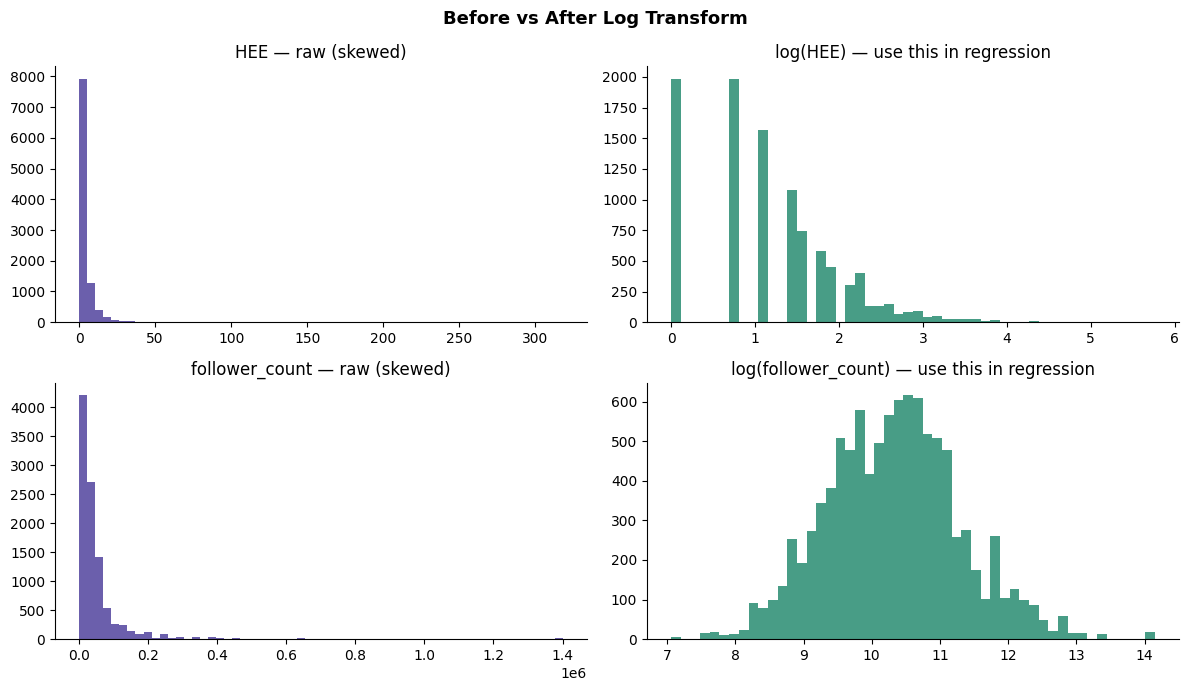

In [46]:
df_clean['log_HEE']            = np.log1p(df_clean['high_effort_engagement'])
df_clean['log_follower_count'] = np.log(df_clean['follower_count'])

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Before vs After Log Transform', fontsize=13, fontweight='bold')

axes[0, 0].hist(df_clean['high_effort_engagement'], bins=60, color='#3a2a90', alpha=0.75)
axes[0, 0].set_title('HEE — raw (skewed)')

axes[0, 1].hist(df_clean['log_HEE'], bins=50, color='#0a7d5e', alpha=0.75)
axes[0, 1].set_title('log(HEE) — use this in regression')

axes[1, 0].hist(df_clean['follower_count'], bins=60, color='#3a2a90', alpha=0.75)
axes[1, 0].set_title('follower_count — raw (skewed)')

axes[1, 1].hist(df_clean['log_follower_count'], bins=50, color='#0a7d5e', alpha=0.75)
axes[1, 1].set_title('log(follower_count) — use this in regression')

for ax in axes.flat:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## Step 5 — Aggregate to Influencer Level

H3 and H5 are about **influencers**, not individual posts.
We average each influencer's post-level metrics across all their posts.

- **IC variables** (`follower_count`, `verified`, `frequency`) — same value repeated for every post → take `first`
- **AA and HEE** — vary per post → take `mean` (represents a typical post for that influencer)

In [47]:
inf_df = df_clean.groupby('influencer_id').agg(
    log_follower_count = ('log_follower_count',              'first'),
    verified           = ('verified',                        'first'),
    freq_posts         = ('Frequency of posts per month',    'first'),
    mean_log_HEE       = ('log_HEE',                         'mean'),
    mean_AA_index      = ('algorithmic_amplification_index', 'mean'),
    mean_reach_growth  = ('reach_growth_rate',               'mean'),
).reset_index()

print(f'Influencer-level dataset: {len(inf_df)} rows')
print(f'\nDescriptive statistics:')
inf_df[['log_follower_count', 'verified', 'freq_posts',
        'mean_log_HEE', 'mean_AA_index', 'mean_reach_growth']].describe().round(3)

Influencer-level dataset: 800 rows

Descriptive statistics:


,log_follower_count,verified,freq_posts,mean_log_HEE,mean_AA_index,mean_reach_growth
count,800.000,800.000,800.000,800.000,800.000,800.000
mean,10.292,0.236,0.521,1.171,-0.007,0.150
std,0.984,0.425,0.152,0.614,0.379,0.046
min,7.059,0.000,0.125,0.000,-0.831,0.032
25%,9.598,0.000,0.417,0.706,-0.279,0.118
50%,10.313,0.000,0.500,1.125,-0.069,0.147
75%,10.929,0.000,0.625,1.521,0.189,0.178
max,14.153,1.000,1.000,4.337,1.764,0.349


---
## Step 6 — Correlation Check

Quick look at how each IC variable correlates with HEE before running the regression.

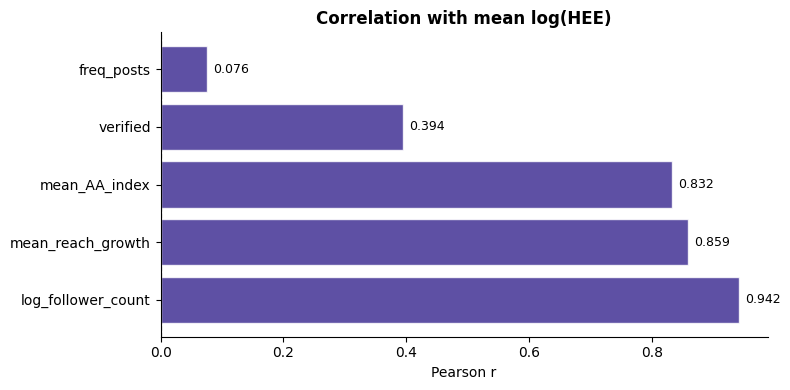


Correlation values:
log_follower_count    0.942
mean_reach_growth     0.859
mean_AA_index         0.832
verified              0.394
freq_posts            0.076


In [48]:
ic_vars = ['log_follower_count', 'verified', 'freq_posts',
           'mean_AA_index', 'mean_reach_growth']

corrs = inf_df[ic_vars].corrwith(inf_df['mean_log_HEE']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#3a2a90' if v > 0 else '#cc3333' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors, alpha=0.82, edgecolor='white')
ax.axvline(0, color='#888', linewidth=0.9, linestyle='--')
ax.set_title('Correlation with mean log(HEE)', fontweight='bold')
ax.set_xlabel('Pearson r')
ax.spines[['top', 'right']].set_visible(False)
for i, (val, name) in enumerate(zip(corrs.values, corrs.index)):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nCorrelation values:')
print(corrs.round(3).to_string())

---
## Step 7 — H3: Influencer Characteristics → HEE

**Multiple linear regression** — all three IC variables predicting mean log(HEE).

Formula: `mean_log_HEE ~ log_follower_count + verified + freq_posts`

In [49]:
model_h3 = smf.ols(
    'mean_log_HEE ~ log_follower_count + verified + freq_posts',
    data=inf_df
).fit()

print(model_h3.summary())

                            OLS Regression Results                            
Dep. Variable:           mean_log_HEE   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     2086.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:17:58   Log-Likelihood:                 128.29
No. Observations:                 800   AIC:                            -248.6
Df Residuals:                     796   BIC:                            -229.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -4.8190      0

### H3 — Coefficient Plot

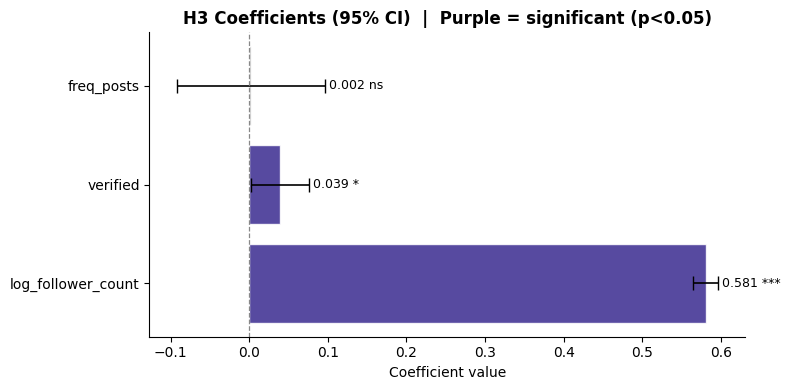

In [50]:
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

params  = model_h3.params.drop('Intercept')
bse     = model_h3.bse.drop('Intercept')
pvalues = model_h3.pvalues.drop('Intercept')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#3a2a90' if p < 0.05 else '#bbbbbb' for p in pvalues]
bars = ax.barh(params.index, params.values,
               xerr=1.96*bse.values, color=colors, alpha=0.85,
               capsize=5, edgecolor='white',
               error_kw={'linewidth': 1.2, 'color': '#555'})
ax.axvline(0, color='#888', linewidth=0.9, linestyle='--')
ax.set_title('H3 Coefficients (95% CI)  |  Purple = significant (p<0.05)',
             fontweight='bold')
ax.set_xlabel('Coefficient value')
ax.spines[['top', 'right']].set_visible(False)
for bar, name in zip(bars, params.index):
    ax.text(params[name] + 1.96*bse[name] + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{params[name]:.3f} {sig_stars(pvalues[name])}",
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

### H3 — Scatter Plots (each IC variable vs HEE)

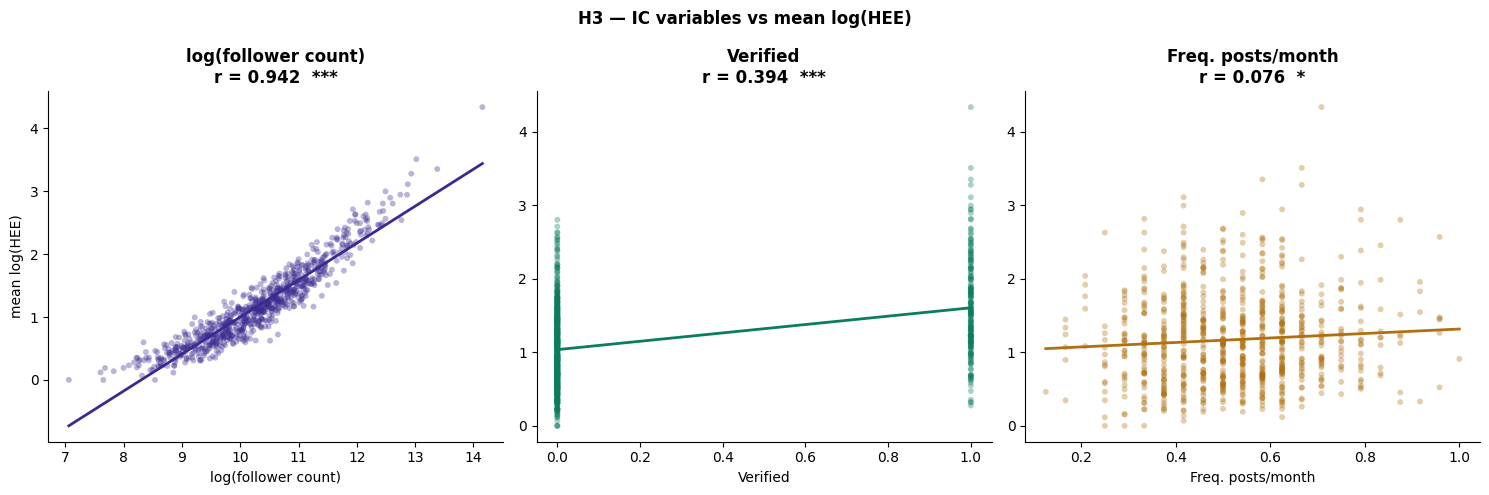

In [51]:
pairs  = [
    ('log_follower_count', 'log(follower count)', '#3a2a90'),
    ('verified',           'Verified',            '#0a7d5e'),
    ('freq_posts',         'Freq. posts/month',   '#b07010'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('H3 — IC variables vs mean log(HEE)', fontsize=12, fontweight='bold')

for ax, (col, label, color) in zip(axes, pairs):
    x = inf_df[col].values
    y = inf_df['mean_log_HEE'].values
    ax.scatter(x, y, alpha=0.35, s=18, color=color, edgecolors='none')
    m, b, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m*x_line + b, color=color, linewidth=2)
    ax.set_title(f'{label}\nr = {r:.3f}  {sig_stars(p)}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('mean log(HEE)' if col == 'log_follower_count' else '')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### H3 — Interpretation

In [52]:
print('='*60)
print('H3 INTERPRETATION')
print('='*60)
print(f"R²      = {model_h3.rsquared:.4f}  → model explains {model_h3.rsquared*100:.1f}% of variance in HEE")
print(f"Adj R²  = {model_h3.rsquared_adj:.4f}")
print(f"F-stat  = {model_h3.fvalue:.2f}  p = {model_h3.f_pvalue:.4f}")
print()
print('Predictor results:')
for name in model_h3.params.index:
    if name == 'Intercept': continue
    coef = model_h3.params[name]
    p    = model_h3.pvalues[name]
    sig  = sig_stars(p)
    print(f"  {name:<30} coef={coef:+.4f}  p={p:.4f}  {sig}")
print()
print('H3 supported?', 'Yes ***' if model_h3.f_pvalue < 0.001 else 'No')

H3 INTERPRETATION
R²      = 0.8871  → model explains 88.7% of variance in HEE
Adj R²  = 0.8867
F-stat  = 2085.59  p = 0.0000

Predictor results:
  log_follower_count             coef=+0.5810  p=0.0000  ***
  verified                       coef=+0.0388  p=0.0383  *
  freq_posts                     coef=+0.0018  p=0.9702  ns

H3 supported? Yes ***


---
## Step 8 — H5: IC → HEE through AA (Mediation)

We run the regression **twice** and compare:

| | Model |
|---|---|
| **Step 1 (baseline)** | IC → HEE (without AA) |
| **Step 2 (mediation)** | IC + AA → HEE (add AA as mediator) |

**Evidence of mediation:**
- R² increases in Step 2
- `log_follower_count` coefficient drops in Step 2
- This means part of IC's effect travels *through* AA before reaching HEE

### H5 — Step 1: IC → HEE (baseline, no mediator)

In [53]:
model_h5_base = smf.ols(
    'mean_log_HEE ~ log_follower_count + verified + freq_posts',
    data=inf_df
).fit()

print(model_h5_base.summary())

                            OLS Regression Results                            
Dep. Variable:           mean_log_HEE   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     2086.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:17:58   Log-Likelihood:                 128.29
No. Observations:                 800   AIC:                            -248.6
Df Residuals:                     796   BIC:                            -229.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -4.8190      0

### H5 — Step 2: IC + AA → HEE (add AA as mediator)

In [54]:
model_h5_med = smf.ols(
    'mean_log_HEE ~ log_follower_count + verified + freq_posts'
                  ' + mean_AA_index + mean_reach_growth',
    data=inf_df
).fit()

print(model_h5_med.summary())

                            OLS Regression Results                            
Dep. Variable:           mean_log_HEE   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     1268.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:17:58   Log-Likelihood:                 133.97
No. Observations:                 800   AIC:                            -255.9
Df Residuals:                     794   BIC:                            -227.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -4.4927      0

### H5 — Mediation Comparison: R² and Coefficient Change

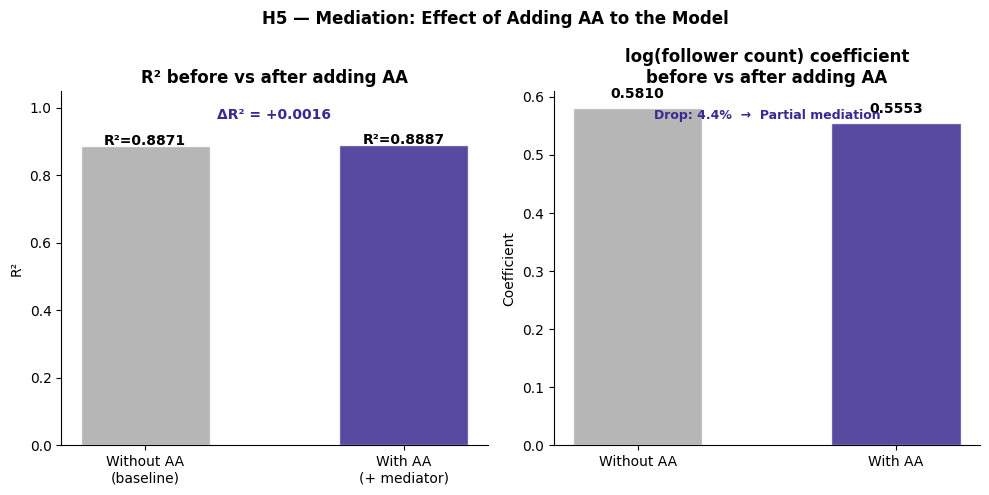

In [55]:
coef_before = model_h5_base.params['log_follower_count']
coef_after  = model_h5_med.params['log_follower_count']
drop_pct    = abs((coef_after - coef_before) / coef_before) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('H5 — Mediation: Effect of Adding AA to the Model',
             fontsize=12, fontweight='bold')

# R² comparison
r2_vals  = [model_h5_base.rsquared, model_h5_med.rsquared]
r2_names = ['Without AA\n(baseline)', 'With AA\n(+ mediator)']
b = axes[0].bar(r2_names, r2_vals, color=['#aaaaaa', '#3a2a90'],
                alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(b, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.003, f'R²={val:.4f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(r2_vals) * 1.18)
axes[0].set_title('R² before vs after adding AA', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].spines[['top', 'right']].set_visible(False)
delta = r2_vals[1] - r2_vals[0]
axes[0].text(0.5, 0.92, f'ΔR² = +{delta:.4f}',
             transform=axes[0].transAxes, ha='center',
             fontsize=10, color='#3a2a90', fontweight='bold')

# Coefficient change
b2 = axes[1].bar(['Without AA', 'With AA'],
                  [coef_before, coef_after],
                  color=['#aaaaaa', '#3a2a90'],
                  alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(b2, [coef_before, coef_after]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + abs(val)*0.03, f'{val:.4f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('log(follower count) coefficient\nbefore vs after adding AA',
                  fontweight='bold')
axes[1].set_ylabel('Coefficient')
axes[1].spines[['top', 'right']].set_visible(False)
med_type = 'Partial mediation' if abs(coef_after) > 0.01 else 'Full mediation'
axes[1].text(0.5, 0.92, f'Drop: {drop_pct:.1f}%  →  {med_type}',
             transform=axes[1].transAxes, ha='center',
             fontsize=9, color='#3a2a90', fontweight='bold')

plt.tight_layout()
plt.show()

### H5 — Scatter Plots

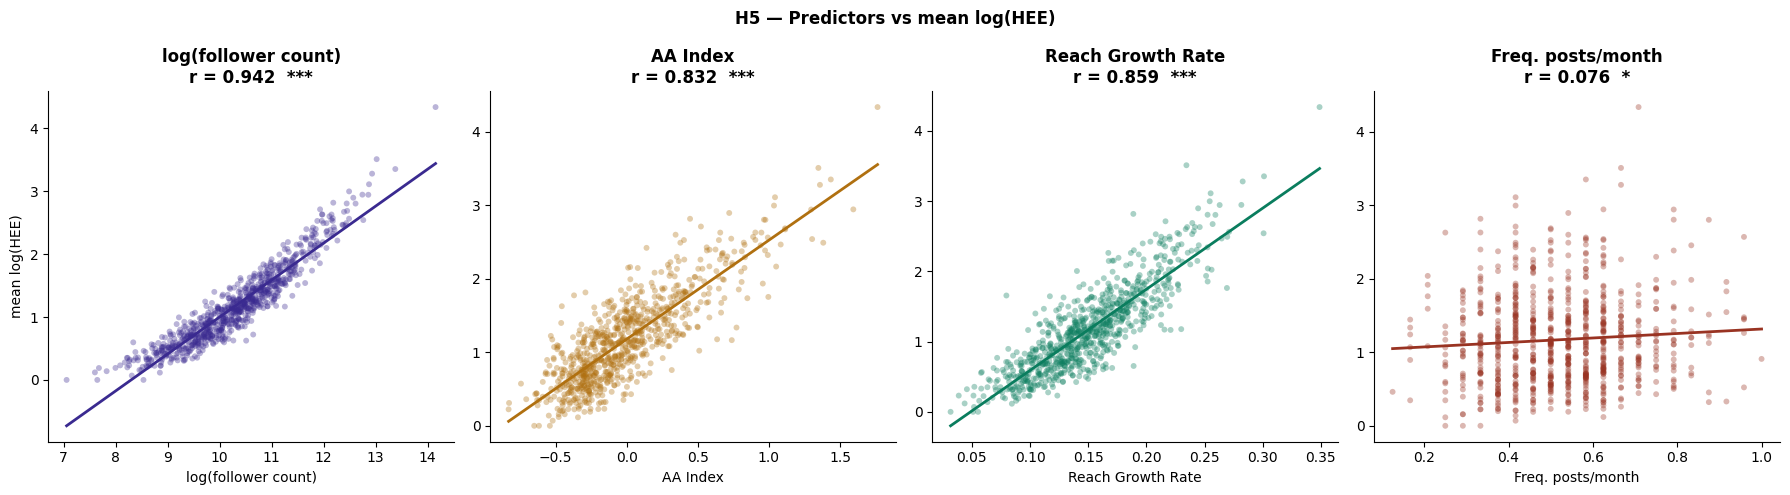

In [56]:
pairs_h5 = [
    ('log_follower_count', 'log(follower count)', '#3a2a90'),
    ('mean_AA_index',      'AA Index',            '#b07010'),
    ('mean_reach_growth',  'Reach Growth Rate',   '#0a7d5e'),
    ('freq_posts',         'Freq. posts/month',   '#993322'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('H5 — Predictors vs mean log(HEE)', fontsize=12, fontweight='bold')

for ax, (col, label, color) in zip(axes, pairs_h5):
    x = inf_df[col].values
    y = inf_df['mean_log_HEE'].values
    ax.scatter(x, y, alpha=0.35, s=18, color=color, edgecolors='none')
    m, b, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m*x_line + b, color=color, linewidth=2)
    ax.set_title(f'{label}\nr = {r:.3f}  {sig_stars(p)}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('mean log(HEE)' if col == 'log_follower_count' else '')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### H5 — Interpretation

In [57]:
print('='*60)
print('H5 MEDIATION INTERPRETATION')
print('='*60)
print(f"R² without AA  = {model_h5_base.rsquared:.4f}")
print(f"R² with AA     = {model_h5_med.rsquared:.4f}")
print(f"ΔR²            = +{model_h5_med.rsquared - model_h5_base.rsquared:.4f}")
print()
print(f"log(follower count) without AA : {coef_before:.4f}")
print(f"log(follower count) with AA    : {coef_after:.4f}")
print(f"Coefficient drop               : {drop_pct:.1f}%")
print()
if drop_pct > 10:
    print('→ AA partially mediates the IC → HEE relationship')
else:
    print('→ Minimal mediation — IC effect is largely direct')
print()
print('H5 supported?', 'Yes ***' if model_h5_med.f_pvalue < 0.001 else 'No')

H5 MEDIATION INTERPRETATION
R² without AA  = 0.8871
R² with AA     = 0.8887
ΔR²            = +0.0016

log(follower count) without AA : 0.5810
log(follower count) with AA    : 0.5553
Coefficient drop               : 4.4%

→ Minimal mediation — IC effect is largely direct

H5 supported? Yes ***


---
## Step 9 — Final Summary

---
## IC Feature — Building a Binary IC Flag

Just like SE, we create a binary IC feature — **IC=1** (high influencer characteristics) and **IC=0** (low).

### How the composite score is built
Three IC variables are combined:
- `log_follower_count` — audience size
- `verified` — platform authority
- `freq_posts` — posting behaviour

Since these are on different scales, we **z-score standardise** each one first, then take an equal-weighted average → one `IC_score` per influencer.

### Threshold (data-driven)
**IC=1** if `IC_score >= mean(IC_score)`

Since the score is z-score standardised, mean = 0, so IC=1 means the influencer scores **above average** across all three dimensions.

The IC flag is defined at **influencer level** then carried down to all their posts.

In [58]:
from sklearn.preprocessing import StandardScaler

# Step 1: Z-score standardise all three IC components
scaler = StandardScaler()
inf_df[['z_followers', 'z_verified', 'z_freq']] = scaler.fit_transform(
    inf_df[['log_follower_count', 'verified', 'freq_posts']]
)

# Step 2: Equal-weighted composite score
inf_df['IC_score'] = (inf_df['z_followers'] + inf_df['z_verified'] + inf_df['z_freq']) / 3

# Step 3: IC=1 if score >= mean (mean=0 since z-score standardised)
threshold_IC = inf_df['IC_score'].mean()
inf_df['IC'] = (inf_df['IC_score'] >= threshold_IC).astype(int)

print(f'IC score — mean: {inf_df["IC_score"].mean():.4f}  std: {inf_df["IC_score"].std():.4f}')
print(f'Threshold: {threshold_IC:.4f}')
print(f'IC=1 influencers: {inf_df["IC"].sum()} ({inf_df["IC"].mean()*100:.1f}%)')
print(f'IC=0 influencers: {(inf_df["IC"]==0).sum()} ({(inf_df["IC"]==0).mean()*100:.1f}%)')

inf_df[['log_follower_count', 'verified', 'freq_posts', 'IC_score', 'IC']].head()

IC score — mean: 0.0000  std: 0.6671
Threshold: 0.0000
IC=1 influencers: 356 (44.5%)
IC=0 influencers: 444 (55.5%)


,log_follower_count,verified,freq_posts,IC_score,IC
0,10.796714,0,0.583333,0.122548,1
1,10.161728,0,0.375000,-0.548874,0
2,10.947696,1,0.416667,0.593581,1
3,11.823032,0,0.375000,0.014447,1
4,10.065861,0,0.291667,-0.763824,0


### IC Feature — Score Distribution and Component Breakdown

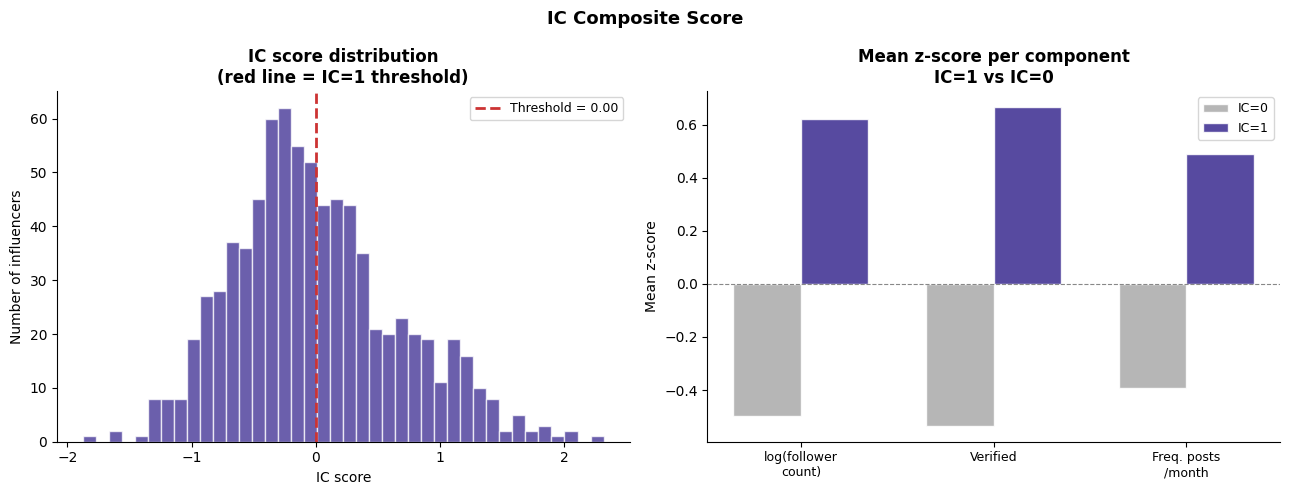

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('IC Composite Score', fontsize=13, fontweight='bold')

# IC score distribution
axes[0].hist(inf_df['IC_score'], bins=40, color='#3a2a90', alpha=0.75, edgecolor='white')
axes[0].axvline(threshold_IC, color='#cc3333', linewidth=2,
                linestyle='--', label=f'Threshold = {threshold_IC:.2f}')
axes[0].set_title('IC score distribution\n(red line = IC=1 threshold)', fontweight='bold')
axes[0].set_xlabel('IC score')
axes[0].set_ylabel('Number of influencers')
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# Mean z-score per component: IC=1 vs IC=0
comp_labels = ['log(follower\ncount)', 'Verified', 'Freq. posts\n/month']
ic1_means   = [inf_df[inf_df['IC']==1][c].mean() for c in ['z_followers','z_verified','z_freq']]
ic0_means   = [inf_df[inf_df['IC']==0][c].mean() for c in ['z_followers','z_verified','z_freq']]
x = np.arange(len(comp_labels))
w = 0.35
axes[1].bar(x - w/2, ic0_means, w, label='IC=0', color='#aaaaaa', alpha=0.85, edgecolor='white')
axes[1].bar(x + w/2, ic1_means, w, label='IC=1', color='#3a2a90', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comp_labels, fontsize=9)
axes[1].axhline(0, color='#888', linewidth=0.8, linestyle='--')
axes[1].set_title('Mean z-score per component\nIC=1 vs IC=0', fontweight='bold')
axes[1].set_ylabel('Mean z-score')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### IC Feature — Carry flag to post level and compare HEE

In [60]:
# Step 4: Merge IC flag from influencer level down to each post
df_clean = df_clean.merge(
    inf_df[['influencer_id', 'IC_score', 'IC']],
    on='influencer_id', how='left'
)

# HEE comparison: IC=1 vs IC=0 posts
hee_ic1    = df_clean[df_clean['IC']==1]['high_effort_engagement']
hee_ic0    = df_clean[df_clean['IC']==0]['high_effort_engagement']
ic_diff    = ((hee_ic1.mean() - hee_ic0.mean()) / hee_ic0.mean()) * 100
t_ic, p_ic = stats.ttest_ind(hee_ic1, hee_ic0)

print('IC=1 vs IC=0 — HEE Comparison (post level)')
print('='*50)
print(f'IC=1 posts: {len(hee_ic1)}  |  IC=0 posts: {len(hee_ic0)}')
print(f'IC=1 mean HEE : {hee_ic1.mean():.3f}  |  median: {hee_ic1.median():.1f}')
print(f'IC=0 mean HEE : {hee_ic0.mean():.3f}  |  median: {hee_ic0.median():.1f}')
print(f'Difference    : {ic_diff:.1f}%')
print(f't-test        : t={t_ic:.3f}, p={p_ic:.4f}')
print(f'Significant   : {"Yes" if p_ic < 0.05 else "No"}')

IC=1 vs IC=0 — HEE Comparison (post level)
IC=1 posts: 5089  |  IC=0 posts: 4911
IC=1 mean HEE : 6.006  |  median: 3.0
IC=0 mean HEE : 2.054  |  median: 1.0
Difference    : 192.5%
t-test        : t=24.709, p=0.0000
Significant   : Yes


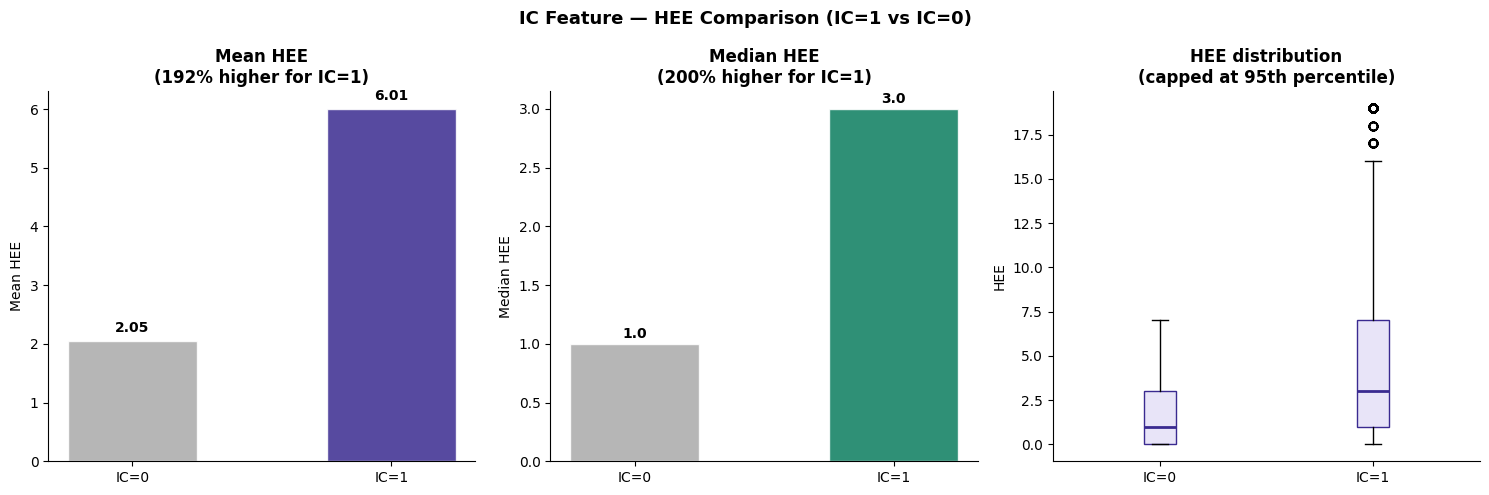

p=0.0000 → difference is statistically significant


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('IC Feature — HEE Comparison (IC=1 vs IC=0)', fontsize=13, fontweight='bold')

# Mean HEE
means_ic = [hee_ic0.mean(), hee_ic1.mean()]
bars = axes[0].bar(['IC=0', 'IC=1'], means_ic,
                   color=['#aaaaaa', '#3a2a90'], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, means_ic):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.15,
                 f'{val:.2f}', ha='center', fontweight='bold')
axes[0].set_title(f'Mean HEE\n({ic_diff:.0f}% higher for IC=1)', fontweight='bold')
axes[0].set_ylabel('Mean HEE')
axes[0].spines[['top', 'right']].set_visible(False)

# Median HEE
meds_ic     = [hee_ic0.median(), hee_ic1.median()]
med_ic_diff = ((hee_ic1.median() - hee_ic0.median()) / hee_ic0.median()) * 100
bars2 = axes[1].bar(['IC=0', 'IC=1'], meds_ic,
                    color=['#aaaaaa', '#0a7d5e'], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars2, meds_ic):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.05,
                 f'{val:.1f}', ha='center', fontweight='bold')
axes[1].set_title(f'Median HEE\n({med_ic_diff:.0f}% higher for IC=1)', fontweight='bold')
axes[1].set_ylabel('Median HEE')
axes[1].spines[['top', 'right']].set_visible(False)

# Box plot
axes[2].boxplot([hee_ic0.clip(upper=hee_ic0.quantile(0.95)),
                 hee_ic1.clip(upper=hee_ic1.quantile(0.95))],
                labels=['IC=0', 'IC=1'], patch_artist=True,
                boxprops=dict(facecolor='#e8e4f8', color='#3a2a90'),
                medianprops=dict(color='#3a2a90', linewidth=2))
axes[2].set_title('HEE distribution\n(capped at 95th percentile)', fontweight='bold')
axes[2].set_ylabel('HEE')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
print(f'p={p_ic:.4f} → difference is {"statistically significant" if p_ic < 0.05 else "not significant"}')

---
## Mediation: IC → SE → HEE

**Question:** Does IC affect HEE *through* SE?
i.e. do high-IC influencers tend to produce posts with more sustained engagement, which then drives more HEE?

**Method — two regression steps:**

| Step | Model | What it tests |
|---|---|---|
| Step 1 (baseline) | IC → HEE (without SE) | Total effect of IC |
| Step 2 (mediation) | IC + SE → HEE (add SE) | Direct effect of IC after accounting for SE |

**Evidence of mediation:**
- IC coefficient drops after adding SE → some of IC's effect travelled *through* SE
- R² increases → SE explains additional variance
- We also check **path a** (IC → SE) separately to confirm IC predicts SE

### Mediation — Path a: Does IC predict SE?

In [62]:
# Build SE flag at post level
df_clean['early_total']  = (df_clean['early_likes'] + df_clean['early_comments']
                             + df_clean['early_shares'])
df_clean['total_engage'] = (df_clean['total_likes'] + df_clean['total_comments']
                             + df_clean['total_shares'])
avg_total    = df_clean['total_engage'].mean()
df_clean['SE'] = ((df_clean['total_engage'] >= 1.5 * df_clean['early_total']) &
                  (df_clean['total_engage'] >= 0.6 * avg_total)).astype(int)

print(f'SE=1 posts: {df_clean["SE"].sum()} ({df_clean["SE"].mean()*100:.1f}%)')
print(f'SE=0 posts: {(df_clean["SE"]==0).sum()} ({(df_clean["SE"]==0).mean()*100:.1f}%)')

# Path a: IC_score → SE
# SE is binary so we use logistic regression for path a
model_path_a = smf.logit('SE ~ IC_score', data=df_clean).fit(disp=0)
print('\nPath a — IC_score → SE (logistic regression):')
print(model_path_a.summary())

SE=1 posts: 909 (9.1%)
SE=0 posts: 9091 (90.9%)

Path a — IC_score → SE (logistic regression):
                           Logit Regression Results                           
Dep. Variable:                     SE   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Sat, 21 Mar 2026   Pseudo R-squ.:                  0.3162
Time:                        00:17:59   Log-Likelihood:                -2083.0
converged:                       True   LL-Null:                       -3046.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.6223      0.072    -50.507      0.000      -3.763      -3.482
IC_score       2.5185      0.071    

### Mediation — Step 1: IC → HEE (baseline, no SE)

In [63]:
model_med_base = smf.ols('log_HEE ~ IC_score', data=df_clean).fit()
print('Step 1 — IC_score → HEE (without SE):')
print(model_med_base.summary())

Step 1 — IC_score → HEE (without SE):
                            OLS Regression Results                            
Dep. Variable:                log_HEE   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     3471.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:17:59   Log-Likelihood:                -11221.
No. Observations:               10000   AIC:                         2.245e+04
Df Residuals:                    9998   BIC:                         2.246e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     

### Mediation — Step 2: IC + SE → HEE (add SE as mediator)

In [64]:
model_med_full = smf.ols('log_HEE ~ IC_score + SE', data=df_clean).fit()
print('Step 2 — IC_score + SE → HEE (SE as mediator):')
print(model_med_full.summary())

Step 2 — IC_score + SE → HEE (SE as mediator):
                            OLS Regression Results                            
Dep. Variable:                log_HEE   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     2307.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:17:59   Log-Likelihood:                -10814.
No. Observations:               10000   AIC:                         2.163e+04
Df Residuals:                    9997   BIC:                         2.165e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Inter

### Mediation — Comparison: R² and Coefficient Change

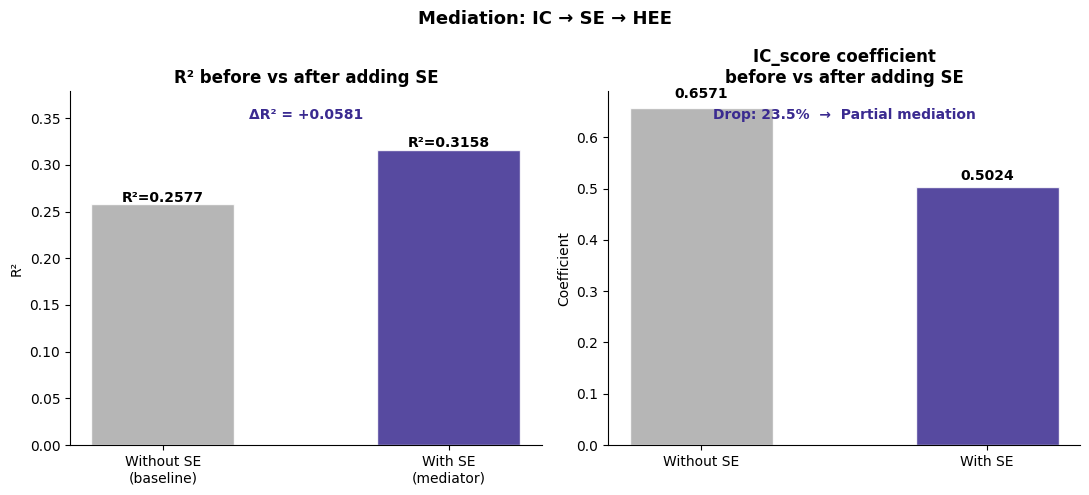

Mediation summary:
  IC_score without SE : 0.6571
  IC_score with SE    : 0.5024
  Coefficient drop    : 23.5%
  R² change           : 0.2577 → 0.3158
  Conclusion          : Partial mediation


In [65]:
coef_ic_before = model_med_base.params['IC_score']
coef_ic_after  = model_med_full.params['IC_score']
drop_pct       = abs((coef_ic_after - coef_ic_before) / coef_ic_before) * 100
med_type       = 'Partial mediation' if abs(coef_ic_after) > 0.01 else 'Full mediation'

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Mediation: IC → SE → HEE', fontsize=13, fontweight='bold')

# R² comparison
r2_vals  = [model_med_base.rsquared, model_med_full.rsquared]
r2_names = ['Without SE\n(baseline)', 'With SE\n(mediator)']
b = axes[0].bar(r2_names, r2_vals, color=['#aaaaaa','#3a2a90'],
                alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(b, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.003,
                 f'R²={val:.4f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(r2_vals)*1.2)
axes[0].set_title('R² before vs after adding SE', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].spines[['top','right']].set_visible(False)
axes[0].text(0.5, 0.92, f'ΔR² = +{r2_vals[1]-r2_vals[0]:.4f}',
             transform=axes[0].transAxes, ha='center',
             color='#3a2a90', fontweight='bold')

# IC_score coefficient before vs after
b2 = axes[1].bar(['Without SE', 'With SE'],
                  [coef_ic_before, coef_ic_after],
                  color=['#aaaaaa','#3a2a90'], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(b2, [coef_ic_before, coef_ic_after]):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+abs(val)*0.03,
                 f'{val:.4f}', ha='center', fontweight='bold')
axes[1].set_title('IC_score coefficient\nbefore vs after adding SE', fontweight='bold')
axes[1].set_ylabel('Coefficient')
axes[1].spines[['top','right']].set_visible(False)
axes[1].text(0.5, 0.92, f'Drop: {drop_pct:.1f}%  →  {med_type}',
             transform=axes[1].transAxes, ha='center',
             color='#3a2a90', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Mediation summary:')
print(f'  IC_score without SE : {coef_ic_before:.4f}')
print(f'  IC_score with SE    : {coef_ic_after:.4f}')
print(f'  Coefficient drop    : {drop_pct:.1f}%')
print(f'  R² change           : {model_med_base.rsquared:.4f} → {model_med_full.rsquared:.4f}')
print(f'  Conclusion          : {med_type}')

---
## Moderation: Does IC Strengthen the SE → HEE Relationship?

**Question:** Do high-IC influencers benefit *more* from sustained engagement than low-IC ones?

**Method:** Add an **interaction term** to the regression:
- Model 1: `IC_score × SE` (continuous × binary)
- Model 2: `IC × SE` (binary × binary)

If the interaction coefficient is **significant**:
- Positive → high-IC influencers get even more HEE from SE
- Negative → high-IC influencers get less additional HEE from SE (SE matters more for low-IC)

In statsmodels formula, `SE:IC_score` adds just the interaction term.

### Moderation — Model 1: IC_score × SE (continuous × binary)

In [66]:
# SE:IC_score adds the interaction term only
# IC_score and SE are included as main effects too
model_mod1 = smf.ols('log_HEE ~ IC_score + SE + SE:IC_score', data=df_clean).fit()
print('Moderation Model 1 — IC_score × SE:')
print(model_mod1.summary())

Moderation Model 1 — IC_score × SE:
                            OLS Regression Results                            
Dep. Variable:                log_HEE   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     1538.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:17:59   Log-Likelihood:                -10814.
No. Observations:               10000   AIC:                         2.164e+04
Df Residuals:                    9996   BIC:                         2.166e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     

### Moderation — Model 2: IC × SE (binary × binary)

In [67]:
model_mod2 = smf.ols('log_HEE ~ IC + SE + IC:SE', data=df_clean).fit()
print('Moderation Model 2 — IC × SE (binary):')
print(model_mod2.summary())

Moderation Model 2 — IC × SE (binary):
                            OLS Regression Results                            
Dep. Variable:                log_HEE   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     1201.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:17:59   Log-Likelihood:                -11172.
No. Observations:               10000   AIC:                         2.235e+04
Df Residuals:                    9996   BIC:                         2.238e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    

### Moderation — Visualisation: SE effect across IC groups

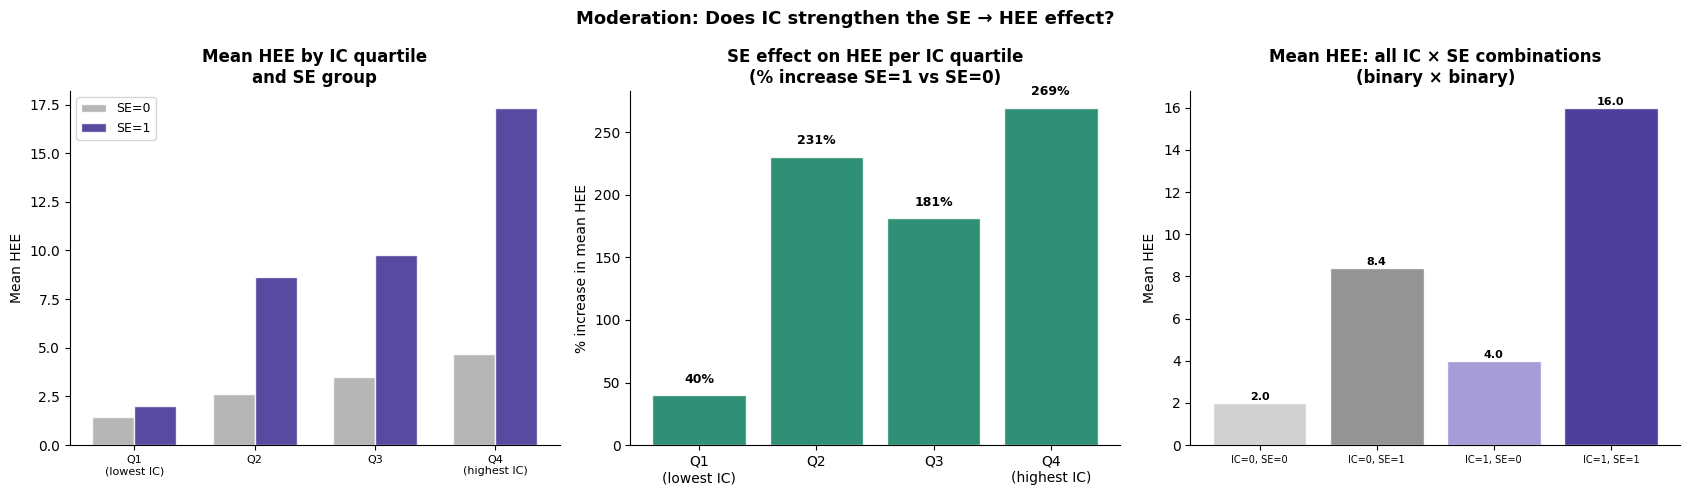

SE effect (% HEE increase) per IC quartile:
  Q1 (lowest IC)      : 40.0%
  Q2                  : 230.5%
  Q3                  : 181.4%
  Q4 (highest IC)     : 269.4%


In [68]:
# Split IC_score into quartiles to show how SE effect changes across IC levels
df_clean['IC_quartile'] = pd.qcut(df_clean['IC_score'], q=4,
                                   labels=['Q1\n(lowest IC)', 'Q2', 'Q3', 'Q4\n(highest IC)'])

quartiles  = ['Q1\n(lowest IC)', 'Q2', 'Q3', 'Q4\n(highest IC)']
hee_se0_q  = [df_clean[(df_clean['IC_quartile']==q) & (df_clean['SE']==0)]
               ['high_effort_engagement'].mean() for q in quartiles]
hee_se1_q  = [df_clean[(df_clean['IC_quartile']==q) & (df_clean['SE']==1)]
               ['high_effort_engagement'].mean() for q in quartiles]
se_effects = [((s1-s0)/s0)*100 for s0, s1 in zip(hee_se0_q, hee_se1_q)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Moderation: Does IC strengthen the SE → HEE effect?',
             fontsize=13, fontweight='bold')

# Grouped bar: HEE by IC quartile and SE
x = np.arange(len(quartiles))
w = 0.35
axes[0].bar(x-w/2, hee_se0_q, w, label='SE=0', color='#aaaaaa', alpha=0.85, edgecolor='white')
axes[0].bar(x+w/2, hee_se1_q, w, label='SE=1', color='#3a2a90', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(quartiles, fontsize=8)
axes[0].set_title('Mean HEE by IC quartile\nand SE group', fontweight='bold')
axes[0].set_ylabel('Mean HEE')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# SE effect (% lift) per IC quartile
bar_colors = ['#0a7d5e' if v > 0 else '#cc3333' for v in se_effects]
bars = axes[1].bar(quartiles, se_effects, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, se_effects):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+10,
                 f'{val:.0f}%', ha='center', fontweight='bold', fontsize=9)
axes[1].axhline(0, color='#888', linewidth=0.8, linestyle='--')
axes[1].set_title('SE effect on HEE per IC quartile\n(% increase SE=1 vs SE=0)',
                  fontweight='bold')
axes[1].set_ylabel('% increase in mean HEE')
axes[1].spines[['top','right']].set_visible(False)

# Binary IC: SE=0 vs SE=1 for IC=0 and IC=1
groups    = ['IC=0, SE=0', 'IC=0, SE=1', 'IC=1, SE=0', 'IC=1, SE=1']
hee_means = [
    df_clean[(df_clean['IC']==0) & (df_clean['SE']==0)]['high_effort_engagement'].mean(),
    df_clean[(df_clean['IC']==0) & (df_clean['SE']==1)]['high_effort_engagement'].mean(),
    df_clean[(df_clean['IC']==1) & (df_clean['SE']==0)]['high_effort_engagement'].mean(),
    df_clean[(df_clean['IC']==1) & (df_clean['SE']==1)]['high_effort_engagement'].mean(),
]
grp_colors = ['#cccccc','#888888','#9b91d4','#3a2a90']
bars2 = axes[2].bar(groups, hee_means, color=grp_colors, alpha=0.9, edgecolor='white')
for bar, val in zip(bars2, hee_means):
    axes[2].text(bar.get_x()+bar.get_width()/2, val+0.15,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=8)
axes[2].set_title('Mean HEE: all IC × SE combinations\n(binary × binary)',
                  fontweight='bold')
axes[2].set_ylabel('Mean HEE')
axes[2].tick_params(axis='x', labelsize=7)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('SE effect (% HEE increase) per IC quartile:')
for q, e in zip(quartiles, se_effects):
    print(f'  {q.replace(chr(10)," "):20s}: {e:.1f}%')

### Moderation — Interpretation

In [69]:
print('='*60)
print('MODERATION INTERPRETATION')
print('='*60)

for label, model, term in [
    ('Model 1 — IC_score × SE', model_mod1, 'SE:IC_score'),
    ('Model 2 — IC × SE (binary)', model_mod2, 'IC:SE'),
]:
    coef = model.params.get(term, None)
    p    = model.pvalues.get(term, None)
    print(f'\n{label}')
    print(f'  R²                    : {model.rsquared:.4f}')
    print(f'  Interaction term ({term})')
    print(f'  Coefficient           : {coef:.4f}')
    print(f'  p-value               : {p:.4f}')
    if p < 0.05:
        direction = 'stronger' if coef > 0 else 'weaker'
        print(f'  → SIGNIFICANT — SE effect is {direction} for high-IC influencers')
        print(f'  → IC MODERATES the SE → HEE relationship')
    else:
        print(f'  → NOT significant — SE has similar effect regardless of IC level')
        print(f'  → IC does NOT moderate the SE → HEE relationship')

MODERATION INTERPRETATION

Model 1 — IC_score × SE
  R²                    : 0.3158
  Interaction term (SE:IC_score)
  Coefficient           : 0.0014
  p-value               : 0.9716
  → NOT significant — SE has similar effect regardless of IC level
  → IC does NOT moderate the SE → HEE relationship

Model 2 — IC × SE (binary)
  R²                    : 0.2650
  Interaction term (IC:SE)
  Coefficient           : 0.0328
  p-value               : 0.7530
  → NOT significant — SE has similar effect regardless of IC level
  → IC does NOT moderate the SE → HEE relationship


In [70]:
print('='*65)
print('  SUMMARY — H3 and H5')
print('='*65)
print(f"{'Hyp':<5} {'Description':<35} {'R²':>7} {'Adj R²':>8} {'F':>9} {'Supported?'}")
print('-'*65)

for hyp, desc, model in [
    ('H3', 'IC → HEE',      model_h3),
    ('H5', 'IC → AA → HEE', model_h5_med),
]:
    fp = model.f_pvalue
    supported = ('Yes ***' if fp < 0.001 else
                 'Yes **'  if fp < 0.01  else
                 'Yes *'   if fp < 0.05  else 'No')
    print(f"{hyp:<5} {desc:<35} "
          f"{model.rsquared:>7.4f} {model.rsquared_adj:>8.4f} "
          f"{model.fvalue:>9.2f}  {supported}")

print('\n  *** p<0.001   ** p<0.01   * p<0.05')

  SUMMARY — H3 and H5
Hyp   Description                              R²   Adj R²         F Supported?
-----------------------------------------------------------------
H3    IC → HEE                             0.8871   0.8867   2085.59  Yes ***
H5    IC → AA → HEE                        0.8887   0.8880   1268.35  Yes ***

  *** p<0.001   ** p<0.01   * p<0.05
